# Why a float32 gradient check is off by 10⁻³, and the cube root that fixes it

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## The check is the suspect

In [1]:
import numpy as np

def lse(z):
    return np.log(np.exp(z).sum())            # every op runs in z's dtype

x = np.array([0.3, -1.2, 2.0])
exact = np.exp(x) / np.exp(x).sum()           # the true gradient, softmax(x), in float64

def fd_error(h, dtype):
    """Max error of a central-difference gradient of lse at x, computed in dtype."""
    xd, fd = x.astype(dtype), np.zeros(3)
    for i in range(3):
        e = np.zeros(3, dtype=dtype); e[i] = h
        fd[i] = (lse(xd + e) - lse(xd - e)) / dtype(2 * h)
    return np.abs(fd - exact).max()

for h in (1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    print(f"float32, h = {h:.0e}: max error {fd_error(h, np.float32):.1e}")

float32, h = 1e-02: max error 1.3e-05
float32, h = 1e-03: max error 5.8e-05
float32, h = 1e-04: max error 1.1e-03
float32, h = 1e-05: max error 5.7e-03
float32, h = 1e-06: max error 3.3e-02


## Why the best step is ε^(1/3)

In [2]:
hs = np.logspace(-1, -9, 81)
for dtype in (np.float32, np.float64):
    eps = np.finfo(dtype).eps
    errs = [fd_error(h, dtype) for h in hs]
    k = int(np.argmin(errs))
    print(f"{dtype.__name__}: eps^(1/3) {eps**(1/3):.1e}, best h {hs[k]:.1e}; "
          f"eps^(2/3) {eps**(2/3):.1e}, best error {errs[k]:.1e}")

float32: eps^(1/3) 4.9e-03, best h 1.3e-02; eps^(2/3) 2.4e-05, best error 5.1e-06
float64: eps^(1/3) 6.1e-06, best h 1.6e-05; eps^(2/3) 3.7e-11, best error 8.2e-12


## A gradient you can trust

In [3]:
class Var:
    """A node on the tape: a value, its adjoint, and how to push the adjoint to its parents."""
    def __init__(self, value, parents=()):
        self.value = np.asarray(value, dtype=float)
        self.grad = np.zeros_like(self.value)
        self.parents = parents            # list of (parent Var, local backward fn)

    def __add__(self, other):
        return Var(self.value + other.value,
                   [(self, lambda g: g), (other, lambda g: g)])

    def __mul__(self, other):
        return Var(self.value * other.value,
                   [(self, lambda g: g * other.value), (other, lambda g: g * self.value)])

    def __matmul__(self, other):
        return Var(self.value @ other.value,
                   [(self, lambda g: g @ other.value.T), (other, lambda g: self.value.T @ g)])

    def exp(self):
        out = np.exp(self.value)
        return Var(out, [(self, lambda g: g * out)])

    def log(self):
        return Var(np.log(self.value), [(self, lambda g: g / self.value)])

    def sum(self):
        return Var(self.value.sum(), [(self, lambda g: g * np.ones_like(self.value))])

    def backward(self):
        order, seen = [], set()
        def visit(v):                      # topological sort of the graph
            if id(v) not in seen:
                seen.add(id(v))
                for p, _ in v.parents:
                    visit(p)
                order.append(v)
        visit(self)
        self.grad = np.ones_like(self.value)
        for v in reversed(order):          # reverse topological order
            for p, local in v.parents:
                p.grad = p.grad + local(v.grad)   # the adjoint rule: sum over children

def logsumexp_naive(z):
    return z.exp().sum().log()

def logsumexp_stable(z):
    c = Var(z.value.max())                 # a constant: no parents, no gradient
    shifted = z + Var(-c.value)
    return shifted.exp().sum().log() + c

def gradcheck(f, x, h=1e-6):
    fd = np.zeros_like(x)
    for i in range(x.size):
        e = np.zeros_like(x); e.flat[i] = h
        fd.flat[i] = (f(Var(x + e)).value - f(Var(x - e)).value) / (2 * h)
    z = Var(x); out = f(z); out.backward()
    return np.abs(z.grad - fd).max()

## Reproduce the numbers quoted in the text

In [4]:
import warnings; warnings.filterwarnings("ignore")
z = np.array([1000.0, 1001.0, 1002.0])
for f in (logsumexp_naive, logsumexp_stable):
    v = Var(z); out = f(v); out.backward()
    print(f.__name__, np.round(out.value, 2), np.round(v.grad, 3))
print("gradcheck float64, h=1e-6:", f"{gradcheck(logsumexp_stable, np.array([0.3, -1.2, 2.0])):.1e}")
rng = np.random.default_rng(0)
X, W1, W2 = rng.standard_normal((8, 4)), rng.standard_normal((4, 5)), rng.standard_normal((5, 1))
def net(A, B):                              # softplus hidden layer, squared output
    h = ((Var(X) @ A).exp() + Var(np.ones((8, 5)))).log()
    y = h @ B
    return (y * y).sum()
e1 = gradcheck(lambda A: net(A, Var(W2)), W1)
e2 = gradcheck(lambda B: net(Var(W1), B), W2)
print(f"two-layer net gradcheck float64: max error {max(e1, e2):.1e}")

logsumexp_naive inf [nan nan nan]
logsumexp_stable 1002.41 [0.09  0.245 0.665]
gradcheck float64, h=1e-6: 4.5e-11
two-layer net gradcheck float64: max error 1.7e-09


## The figure

In [5]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

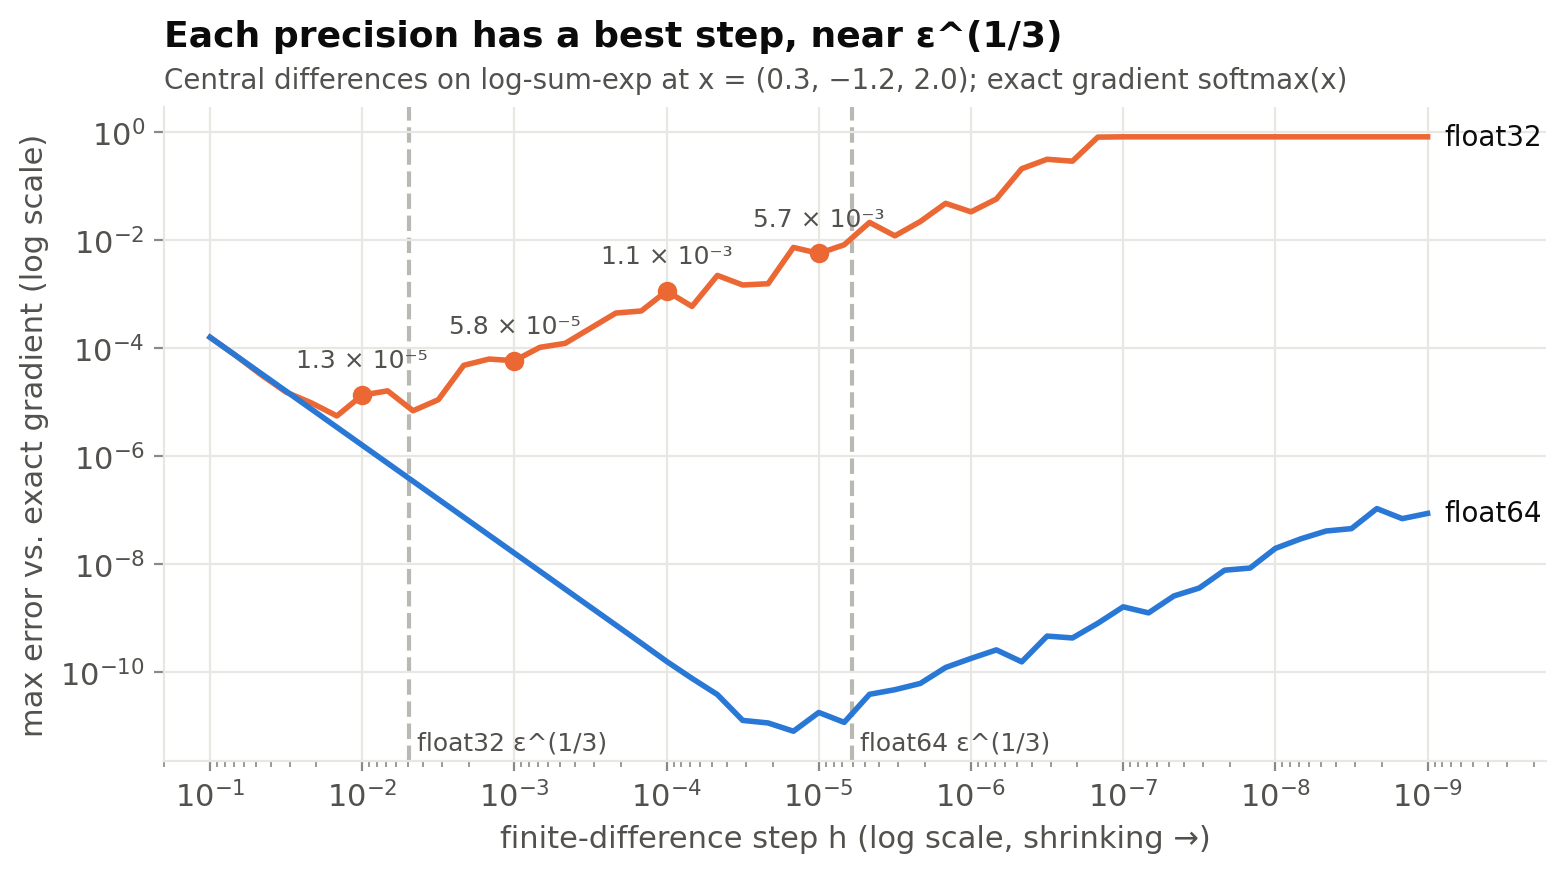

In [6]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    x = np.array([0.3, -1.2, 2.0])
    exact = np.exp(x) / np.exp(x).sum()


    def err(h, dt):
        xd = x.astype(dt)
        lse = lambda z: np.log(np.exp(z).sum())
        fd = np.zeros(3)
        for i in range(3):
            e = np.zeros(3, dtype=dt); e[i] = h
            fd[i] = (lse(xd + e) - lse(xd - e)) / dt(2 * h)
        return np.abs(fd - exact).max()


    hs = np.logspace(-1, -9, 49)
    table_h = [1e-2, 1e-3, 1e-4, 1e-5]
    f, ax = fig()
    for dt, c, name in ((np.float32, S2, "float32"), (np.float64, S1, "float64")):
        e = np.array([err(h, dt) for h in hs])
        ax.plot(hs, e, color=c)
        label_end(ax, hs[-1], e[-1], name, c, dx=6)
        print(name, [f"{err(h, dt):.1e}" for h in table_h])
    e32 = [err(h, np.float32) for h in table_h]
    ax.plot(table_h, e32, "o", color=S2, ms=6)
    for h, v in zip(table_h, e32):
        m, ex = f"{v:.1e}".split("e")
        ax.annotate(f"{m} × 10{''.join('⁰¹²³⁴⁵⁶⁷⁸⁹'[int(ch)] if ch.isdigit() else '⁻' for ch in str(int(ex)))}",
                    (h, v), xytext=(0, 10), textcoords="offset points",
                    color=INK_2, fontsize=9, ha="center")
    for dt, name in ((np.float32, "float32"), (np.float64, "float64")):
        r = np.finfo(dt).eps ** (1 / 3)
        ax.axvline(r, color=NEUTRAL, lw=1.5, ls="--", zorder=0)
        ax.text(r, 3e-12, f" {name} ε^(1/3)", color=INK_2, fontsize=9, ha="left", va="bottom")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlim(2e-1, 1e-9 / 6)
    ax.set_xlabel("finite-difference step h (log scale, shrinking →)")
    ax.set_ylabel("max error vs. exact gradient (log scale)")
    ax.set_title("Each precision has a best step, near ε^(1/3)")
    subtitle(ax, "Central differences on log-sum-exp at x = (0.3, −1.2, 2.0); exact gradient softmax(x)")
    save(f, pathlib.Path(__file__).parent / "04-gradcheck-step-size.png")
import matplotlib.pyplot as plt
plt.show()